# 05 — Explainability & Interpretability: LSTM-CNN vs TCN v3
**PTB-XL ECG Forecasting (4.9s → 4.9s)**

Techniques:
1. **Gradient × Input** — which input timesteps/leads drive each prediction
2. **Temporal importance** — which past time regions matter most
3. **Lead importance** — which ECG leads are most influential
4. **Occlusion sensitivity** — loss increase when each lead is zeroed out
5. **Receptive field analysis** — WaveNet-specific: which input region each output sees
6. **Error decomposition** — where and why each model makes mistakes
7. **Side-by-side comparison** — WaveNet vs TCN v3 on all metrics


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter1d
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 120, 'savefig.dpi': 150,
})
print(f"Device: {DEVICE}")
print("✅ Imports ready")

Device: cpu
✅ Imports ready


In [2]:
# CELL 2 — PATHS & CONFIG
SAVE_DIR  = os.path.join('..', 'data', 'processed')
CKPT_DIR  = os.path.join('..', 'reports', 'checkpoints')
FIG_DIR   = os.path.join('..', 'reports', 'figures', 'explainability')
os.makedirs(FIG_DIR, exist_ok=True)

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']
LEAD_NAMES = cfg['lead_names']

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {name}")

print(f"Input   : {INPUT_LEN} samples = {INPUT_LEN/FS:.2f}s")
print(f"Horizon : {HORIZON}  samples = {HORIZON/FS:.2f}s")
print("✅ Config loaded")

Input   : 490 samples = 4.90s
Horizon : 490  samples = 4.90s
✅ Config loaded


In [3]:
# CELL 3 — LOAD TEST DATA
X_test = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

N_XAI    = min(100, len(X_test))
X_xai    = X_test[:N_XAI]
y_xai    = y_test[:N_XAI]

print(f"X_xai : {X_xai.shape}   y_xai : {y_xai.shape}")
print("✅ Data loaded")

X_xai : (100, 490, 12)   y_xai : (100, 490, 12)
✅ Data loaded


In [4]:
# CELL 4 — MODEL DEFINITIONS (exact match to training notebooks)

# ── WaveNet ───────────────────────────────────────────────────────────
class DilatedBlock(nn.Module):
    def __init__(self, channels, dilation, kernel_size=7, dropout=0.15):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad, bias=False)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad, bias=False)
        self.bn1  = nn.BatchNorm1d(channels)
        self.bn2  = nn.BatchNorm1d(channels)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        res = x
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = F.gelu(self.bn2(self.conv2(out)))
        out = self.drop(out)
        return out + res

class WaveNetForecaster(nn.Module):
    DILATIONS   = [1, 2, 4, 8, 16, 32, 64]
    CHANNELS    = 64
    KERNEL_SIZE = 7
    def __init__(self, n_leads=12, horizon=490, dropout=0.15):
        super().__init__()
        self.horizon = horizon; self.n_leads = n_leads
        self.input_proj = nn.Sequential(
            nn.Conv1d(n_leads, self.CHANNELS, 1, bias=False),
            nn.BatchNorm1d(self.CHANNELS), nn.GELU())
        self.blocks = nn.ModuleList([
            DilatedBlock(self.CHANNELS, d, self.KERNEL_SIZE, dropout)
            for d in self.DILATIONS])
        self.output_proj = nn.Sequential(
            nn.Conv1d(self.CHANNELS, self.CHANNELS, 1, bias=False),
            nn.BatchNorm1d(self.CHANNELS), nn.GELU(),
            nn.Conv1d(self.CHANNELS, n_leads, 1))
    def forward(self, x):
        out = self.input_proj(x)
        for block in self.blocks: out = block(out)
        return self.output_proj(out).permute(0, 2, 1)

# ── TCN v3 ────────────────────────────────────────────────────────────
class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        mid = out_ch // 3
        self.branch3  = nn.Sequential(nn.Conv1d(in_ch, mid, 3,  padding=1, bias=False), nn.BatchNorm1d(mid), nn.GELU())
        self.branch7  = nn.Sequential(nn.Conv1d(in_ch, mid, 7,  padding=3, bias=False), nn.BatchNorm1d(mid), nn.GELU())
        self.branch15 = nn.Sequential(nn.Conv1d(in_ch, mid, 15, padding=7, bias=False), nn.BatchNorm1d(mid), nn.GELU())
        self.project  = nn.Sequential(nn.Conv1d(mid*3, out_ch, 1, bias=False), nn.BatchNorm1d(out_ch), nn.GELU())
        self.residual = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, bias=False), nn.BatchNorm1d(out_ch)) if in_ch != out_ch else nn.Identity()
        self.drop     = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([self.branch3(x), self.branch7(x), self.branch15(x)], dim=1)
        return F.gelu(self.drop(self.project(out)) + self.residual(x))

class TCNv3Forecaster(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.2):
        super().__init__()
        self.horizon = horizon; self.n_leads = n_leads
        self.enc1 = nn.Sequential(MultiScaleBlock(n_leads, 64,  dropout), nn.MaxPool1d(2))
        self.enc2 = nn.Sequential(MultiScaleBlock(64,      128, dropout), nn.MaxPool1d(2))
        self.enc3 = MultiScaleBlock(128, 128, dropout)
        self.attn = nn.Sequential(nn.Linear(128, 64), nn.Tanh(), nn.Linear(64, 1))
        self.decoder = nn.Sequential(
            nn.LayerNorm(128), nn.Dropout(dropout),
            nn.Linear(128, 256), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(256, horizon * n_leads))
    def forward(self, x):
        x = self.enc3(self.enc2(self.enc1(x))).permute(0, 2, 1)
        ctx = (torch.softmax(self.attn(x), dim=1) * x).sum(dim=1)
        return self.decoder(ctx).view(-1, self.horizon, self.n_leads)

print("✅ Both model classes defined")

✅ Both model classes defined


In [5]:
# CELL 5 — LOAD WEIGHTS
def load_ckpt(model, path, name):
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
        sd   = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
        model.load_state_dict(sd)
        n = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"✅ {name} loaded  ({n:,} params)")
    else:
        print(f"⚠  {name} checkpoint not found — using random weights")
    model.eval()

wave_model = WaveNetForecaster(n_leads=N_LEADS, horizon=HORIZON, dropout=0.15).to(DEVICE)
tcn_model  = TCNv3Forecaster( n_leads=N_LEADS,  horizon=HORIZON, dropout=0.2).to(DEVICE)

load_ckpt(wave_model, os.path.join(CKPT_DIR, 'CNN-LSTM_final.pt'), 'LSTM-CNN')
load_ckpt(tcn_model,  os.path.join(CKPT_DIR, 'TCN_final.pt'),      'TCN v3')

✅ LSTM-CNN loaded  (409,100 params)
✅ TCN v3 loaded  (1,807,563 params)


In [6]:
# CELL 6 — GRADIENT × INPUT ATTRIBUTION
# For each model: gradient of MSE loss w.r.t. input, multiplied by input.
# Positive = feature pushed prediction toward ground truth.
# Negative = feature pulled it away.
# Shape: (N, INPUT_LEN, N_LEADS) — time × lead attribution map.

def gradient_x_input(model, X_np, y_np, channel_first=True):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_np, dtype=torch.float32).to(DEVICE)

    if channel_first:
        X_in = X_t.permute(0, 2, 1).requires_grad_(True)  # (B,12,T)
    else:
        X_in = X_t.clone().requires_grad_(True)

    pred = model(X_in)
    loss = F.mse_loss(pred, y_t)
    loss.backward()

    grad = X_in.grad.detach()           # (B, 12, T) or (B, T, 12)
    attr = (grad * X_in.detach())

    if channel_first:
        attr = attr.permute(0, 2, 1)    # → (B, T, 12)
        pred = pred.detach()
    return attr.cpu().numpy(), pred.cpu().numpy()

print("Computing Gradient × Input for LSTM CNN …")
wave_attr, wave_preds = gradient_x_input(wave_model, X_xai, y_xai, channel_first=True)
print(f"WaveNet attributions: {wave_attr.shape}")

print("Computing Gradient × Input for TCN …")
tcn_attr, tcn_preds = gradient_x_input(tcn_model, X_xai, y_xai, channel_first=True)
print(f"TCN v3  attributions: {tcn_attr.shape}")
print("✅ Attributions ready")

Computing Gradient × Input for LSTM CNN …
WaveNet attributions: (100, 490, 12)
Computing Gradient × Input for TCN …
TCN v3  attributions: (100, 490, 12)
✅ Attributions ready


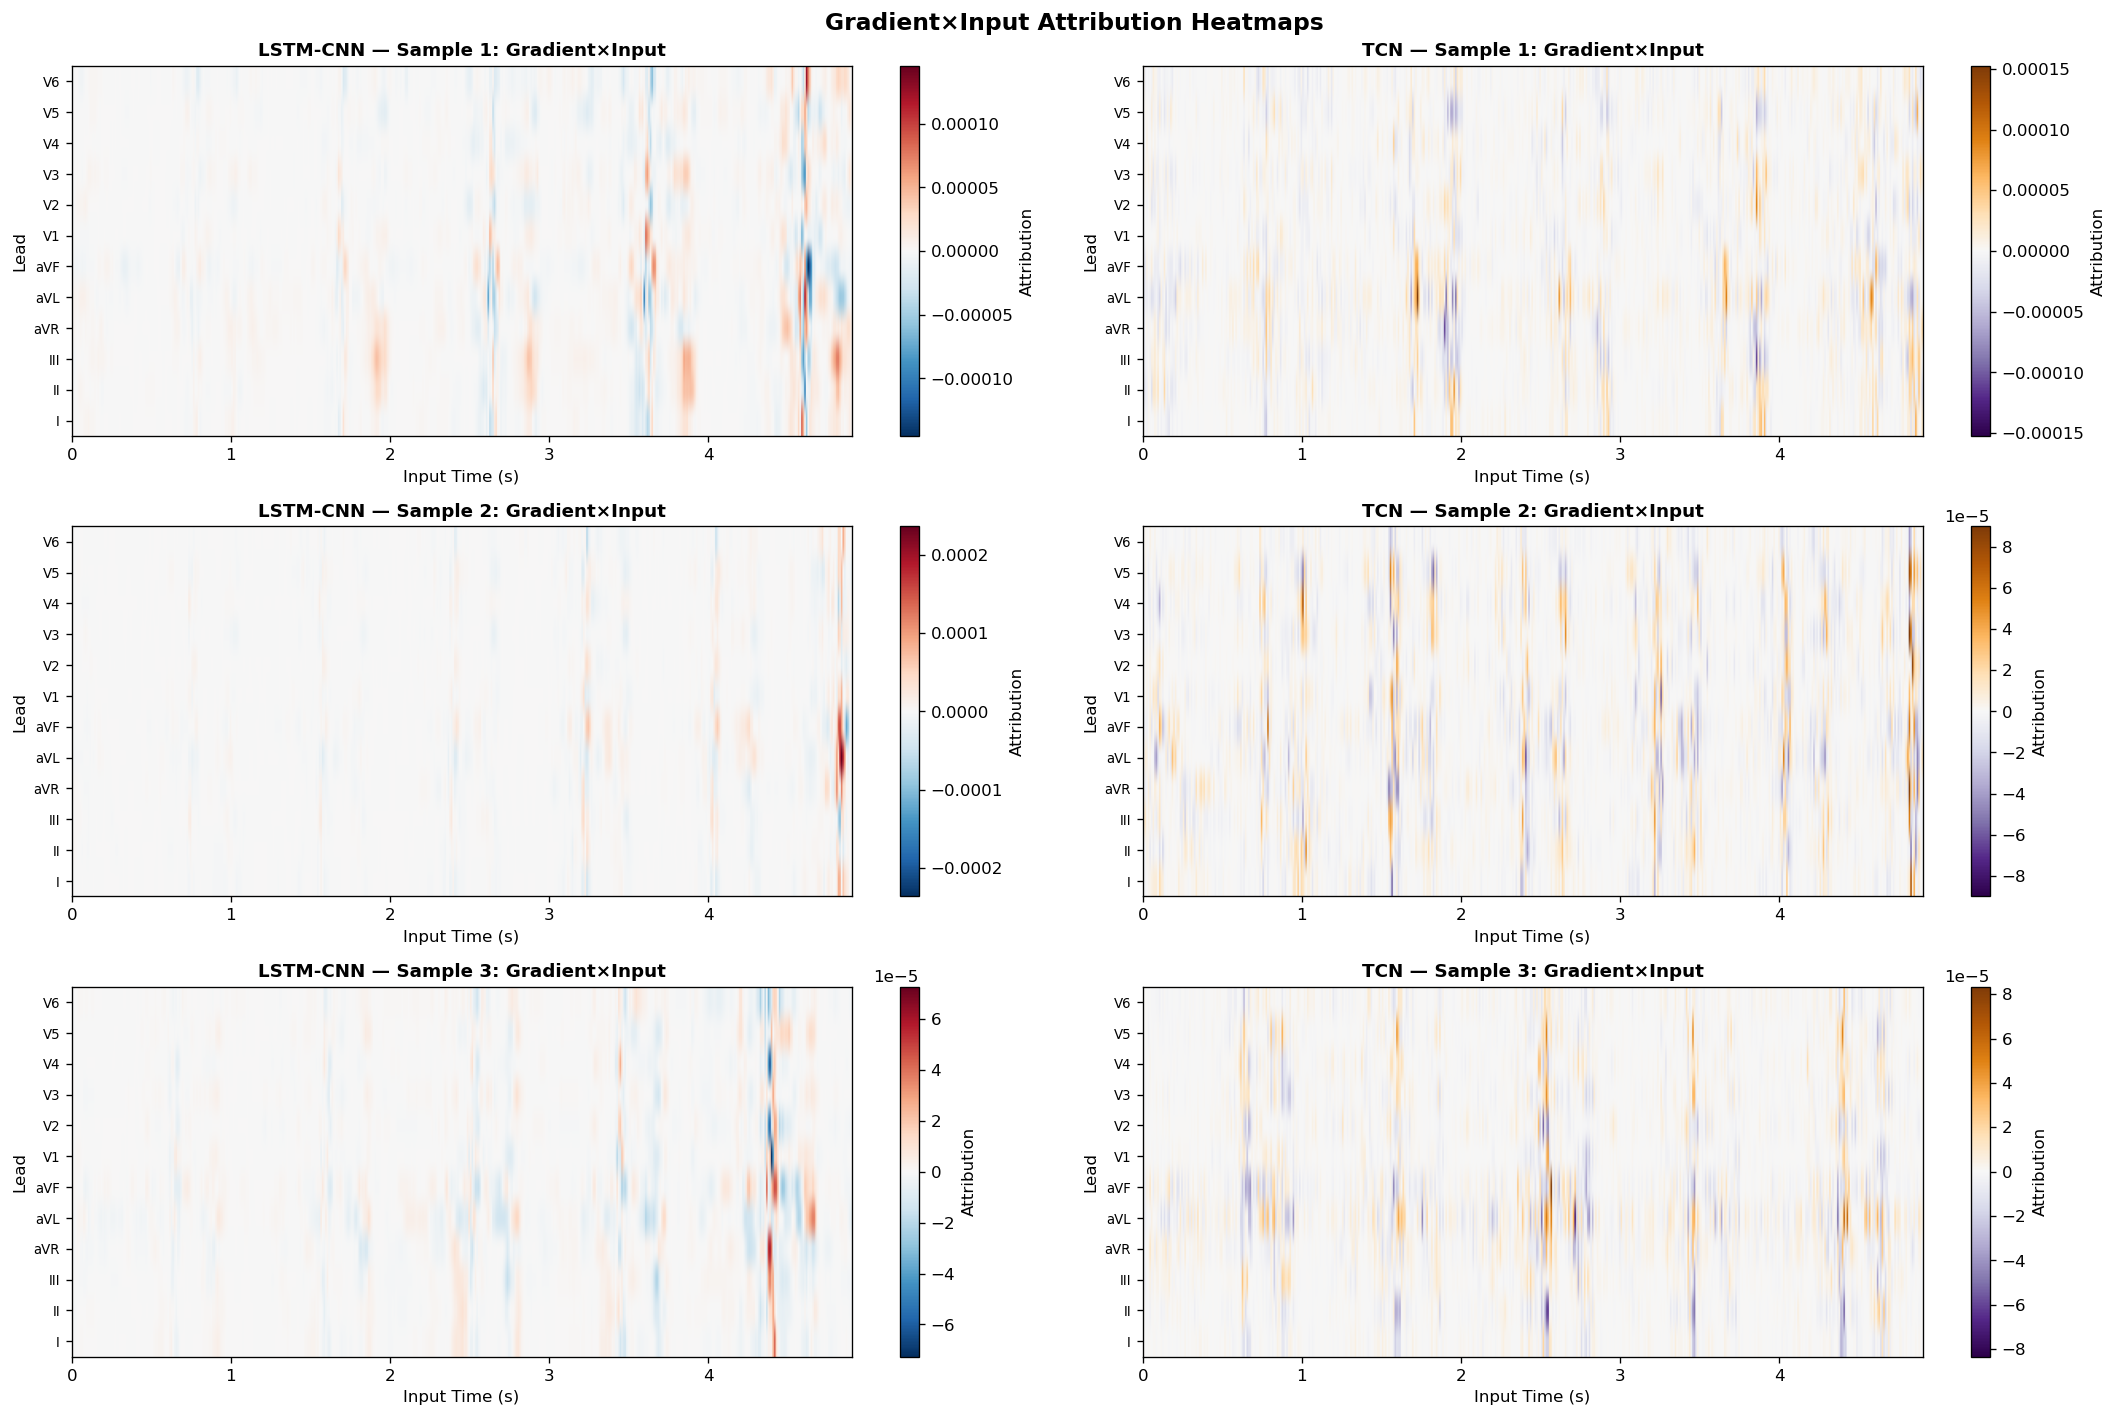

✅ Saved → 01_attribution_heatmaps.png


In [7]:
# CELL 7 — ATTRIBUTION HEATMAPS (3 samples, both models)
n_viz = 3
t_in  = np.arange(INPUT_LEN) / FS

fig, axes = plt.subplots(n_viz, 2, figsize=(18, 4*n_viz))

for idx in range(n_viz):
    for col, (name, attr, color) in enumerate([
        ('LSTM-CNN', wave_attr, 'RdBu_r'),
        ('TCN',  tcn_attr,  'PuOr_r'),
    ]):
        ax   = axes[idx, col]
        data = attr[idx].T          # (12, T)
        vmax = max(abs(data.min()), abs(data.max())) + 1e-8
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im   = ax.imshow(data, aspect='auto', cmap=color, norm=norm,
                         extent=[0, INPUT_LEN/FS, -0.5, N_LEADS-0.5])
        ax.set_yticks(range(N_LEADS))
        ax.set_yticklabels(LEAD_NAMES, fontsize=8)
        ax.set_xlabel('Input Time (s)'); ax.set_ylabel('Lead')
        ax.set_title(f'{name} — Sample {idx+1}: Gradient×Input',
                     fontweight='bold', fontsize=11)
        plt.colorbar(im, ax=ax, label='Attribution')

plt.suptitle('Gradient×Input Attribution Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('01_attribution_heatmaps.png')

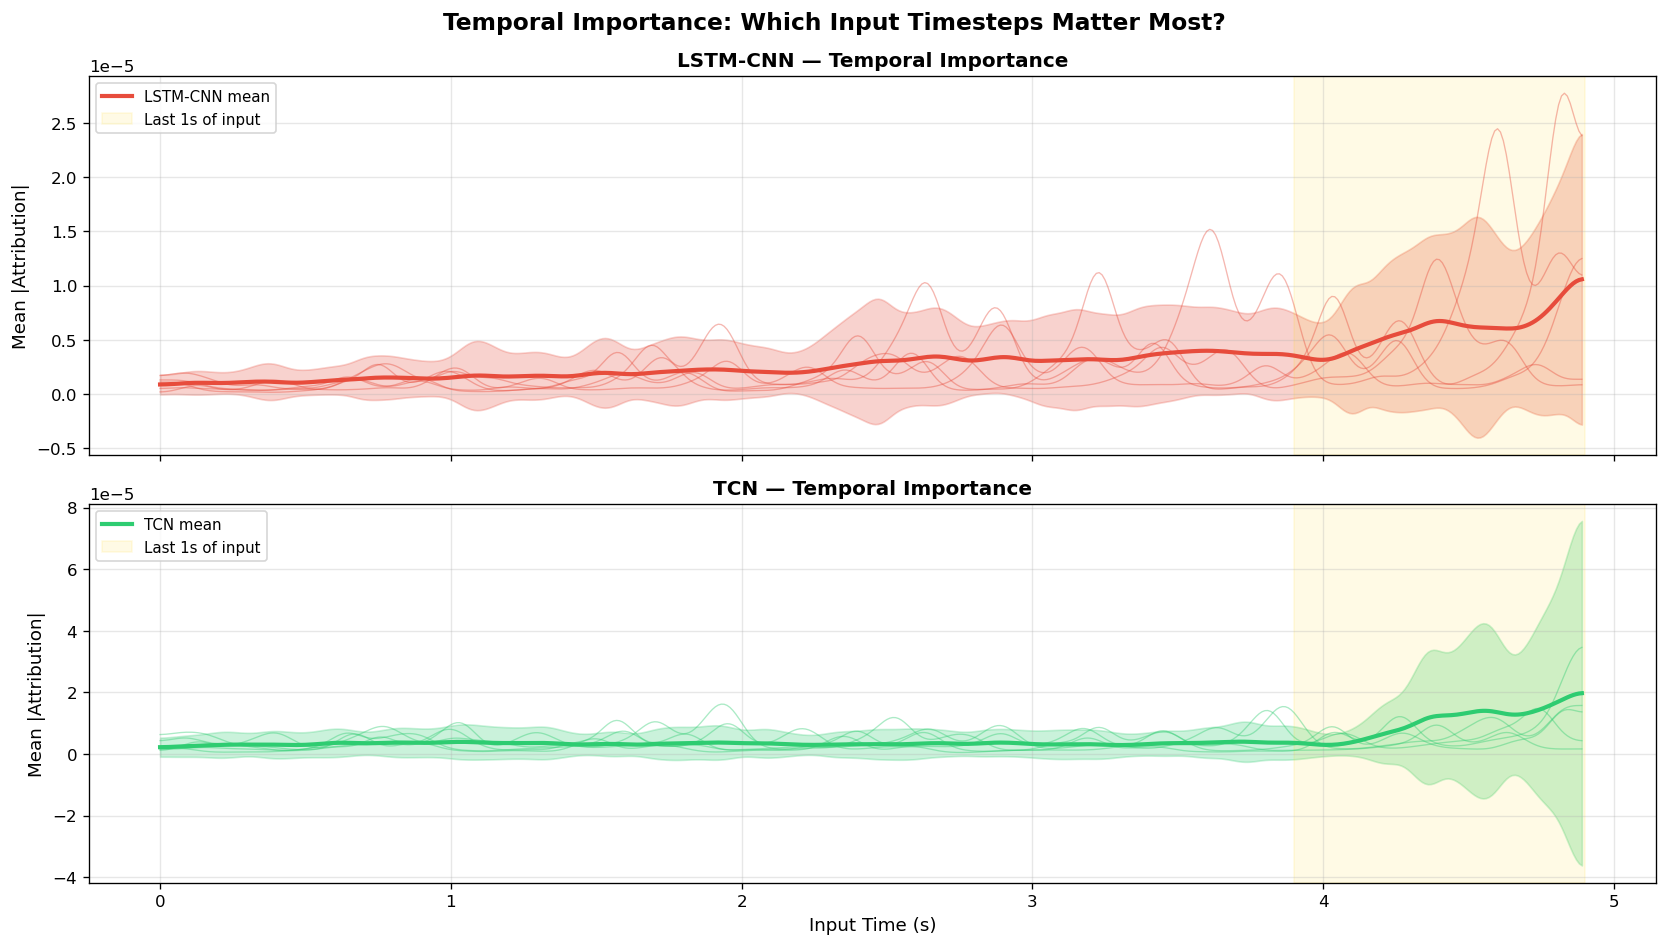

✅ Saved → 02_temporal_importance.png


In [8]:
# CELL 8 — TEMPORAL IMPORTANCE (which input time regions matter most)
wave_time_imp = np.abs(wave_attr).mean(axis=2)   # (N, T)
tcn_time_imp  = np.abs(tcn_attr).mean(axis=2)
t_in = np.arange(INPUT_LEN) / FS

# Smooth for readability
wave_smooth = np.array([gaussian_filter1d(r, sigma=5) for r in wave_time_imp])
tcn_smooth  = np.array([gaussian_filter1d(r, sigma=5) for r in tcn_time_imp])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, smooth, name, color in [
    (axes[0], wave_smooth, 'LSTM-CNN', '#e74c3c'),
    (axes[1], tcn_smooth,  'TCN',  '#2ecc71'),
]:
    mean = smooth.mean(0); std = smooth.std(0)
    ax.fill_between(t_in, mean-std, mean+std, alpha=0.25, color=color)
    ax.plot(t_in, mean, color=color, lw=2.5, label=f'{name} mean')
    for i in range(min(5, len(smooth))):
        ax.plot(t_in, smooth[i], lw=0.8, alpha=0.4, color=color)
    # Highlight last 1s of input (most recent context)
    ax.axvspan((INPUT_LEN-100)/FS, INPUT_LEN/FS,
               alpha=0.1, color='gold', label='Last 1s of input')
    ax.set_ylabel('Mean |Attribution|', fontsize=11)
    ax.set_title(f'{name} — Temporal Importance', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Input Time (s)', fontsize=11)
plt.suptitle('Temporal Importance: Which Input Timesteps Matter Most?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('02_temporal_importance.png')

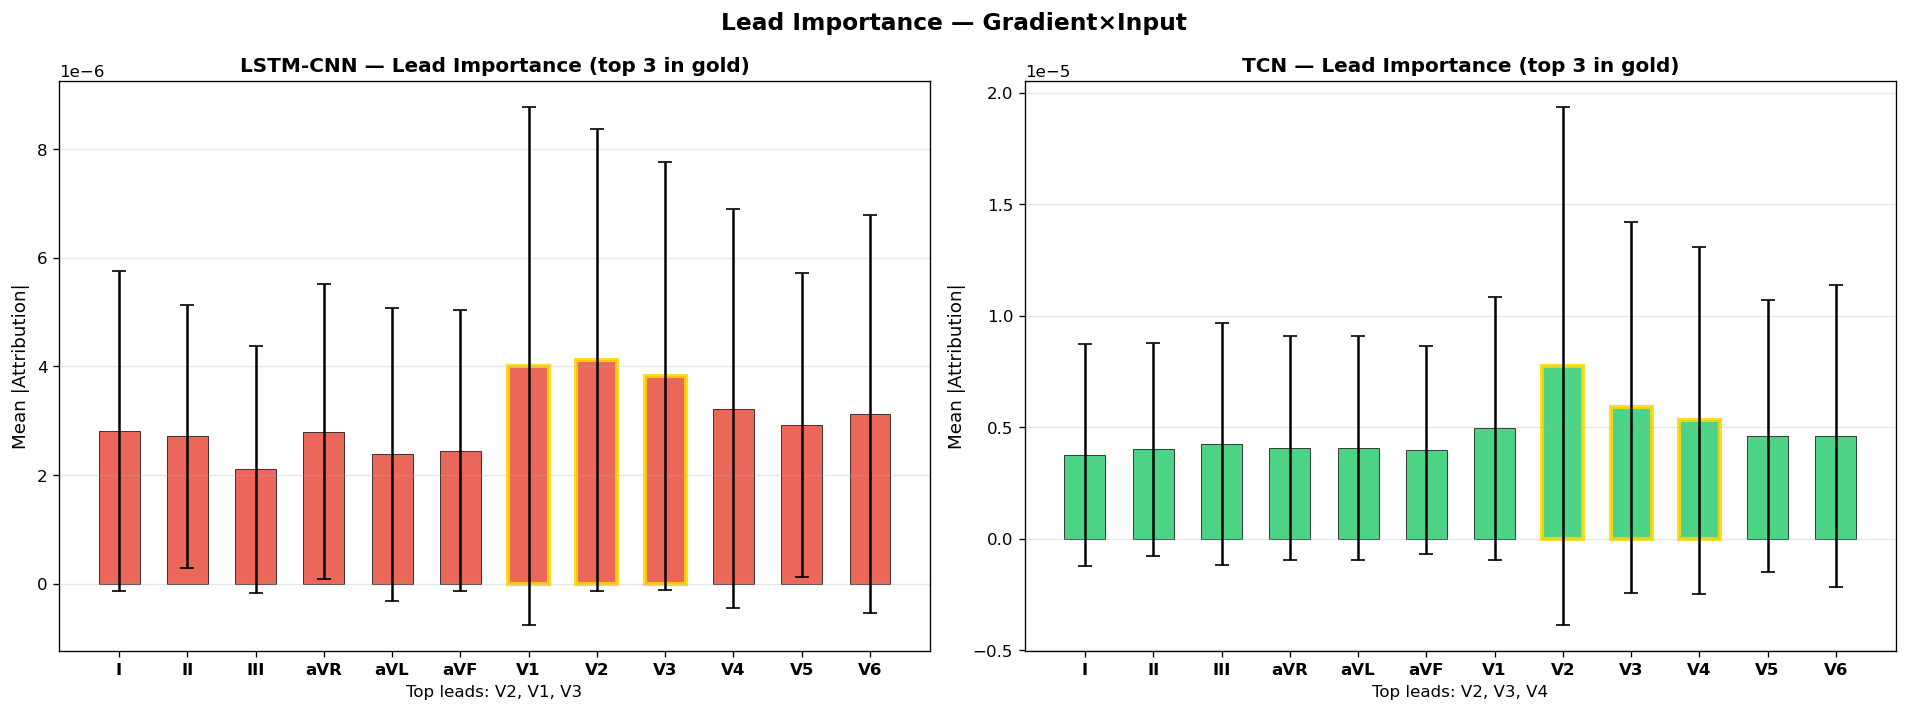

✅ Saved → 03_lead_importance.png
WaveNet top leads: ['V2', 'V1', 'V3']
TCN v3  top leads: ['V2', 'V3', 'V4']


In [9]:
# CELL 9 — LEAD IMPORTANCE (gradient-based)
wave_lead_imp = np.abs(wave_attr).mean(axis=1)   # (N, 12)
tcn_lead_imp  = np.abs(tcn_attr).mean(axis=1)

wave_lead_mean = wave_lead_imp.mean(0); wave_lead_std = wave_lead_imp.std(0)
tcn_lead_mean  = tcn_lead_imp.mean(0);  tcn_lead_std  = tcn_lead_imp.std(0)

x = np.arange(N_LEADS); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mean, std, name, color in [
    (axes[0], wave_lead_mean, wave_lead_std, 'LSTM-CNN', '#e74c3c'),
    (axes[1], tcn_lead_mean,  tcn_lead_std,  'TCN',  '#2ecc71'),
]:
    bars = ax.bar(x, mean, width=0.6, color=color, alpha=0.85,
                  edgecolor='black', lw=0.5, yerr=std, capsize=4)
    top3 = np.argsort(mean)[-3:]
    for i in top3:
        bars[i].set_edgecolor('gold'); bars[i].set_linewidth(2.5)
    ax.set_xticks(x); ax.set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean |Attribution|', fontsize=11)
    ax.set_title(f'{name} — Lead Importance (top 3 in gold)',
                 fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    top_names = [LEAD_NAMES[i] for i in np.argsort(mean)[-3:][::-1]]
    ax.set_xlabel(f'Top leads: {", ".join(top_names)}', fontsize=10)

plt.suptitle('Lead Importance — Gradient×Input', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('03_lead_importance.png')

print(f"WaveNet top leads: {[LEAD_NAMES[i] for i in np.argsort(wave_lead_mean)[-3:][::-1]]}")
print(f"TCN v3  top leads: {[LEAD_NAMES[i] for i in np.argsort(tcn_lead_mean)[-3:][::-1]]}")

Computing occlusion sensitivity …


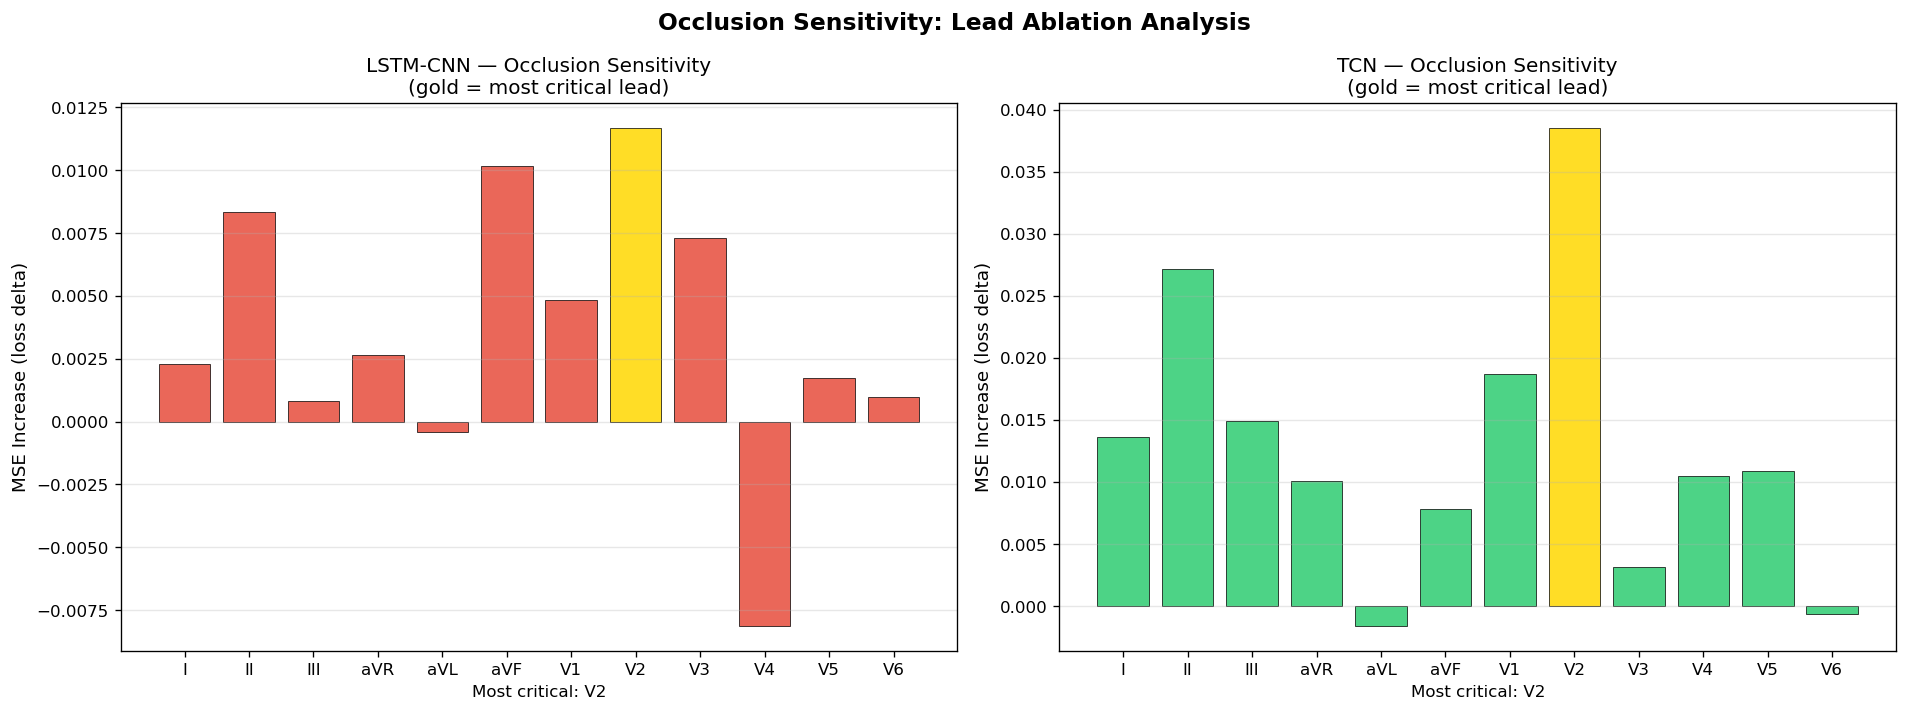

✅ Saved → 04_occlusion_sensitivity.png
WaveNet most critical lead: V2
TCN v3  most critical lead: V2


In [13]:
# CELL 10 — OCCLUSION SENSITIVITY
# Zero out each lead in turn, measure MSE increase.
# Higher increase = model depends more on that lead.

def occlusion_sensitivity(model, X_np, y_np, channel_first=True):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_np, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        Xin = X_t.permute(0,2,1) if channel_first else X_t
        baseline = F.mse_loss(model(Xin), y_t).item()

    impacts = []
    for li in range(N_LEADS):
        X_occ = X_t.clone()
        X_occ[:, :, li] = 0.0   # zero out lead li
        with torch.no_grad():
            Xin = X_occ.permute(0,2,1) if channel_first else X_occ
            occ_loss = F.mse_loss(model(Xin), y_t).item()
        impacts.append(occ_loss - baseline)
    return np.array(impacts), baseline

print("Computing occlusion sensitivity …")
# Run in batches to avoid memory issues
batch = 20
wave_occ_all, tcn_occ_all = [], []
for i in range(0, N_XAI, batch):
    e = min(i+batch, N_XAI)
    wo, _ = occlusion_sensitivity(wave_model, X_xai[i:e], y_xai[i:e])
    to, _ = occlusion_sensitivity(tcn_model,  X_xai[i:e], y_xai[i:e])
    wave_occ_all.append(wo); tcn_occ_all.append(to)

wave_occ = np.array(wave_occ_all).mean(0)
tcn_occ  = np.array(tcn_occ_all).mean(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, occ, name, color in [
    (axes[0], wave_occ, 'LSTM-CNN', '#e74c3c'),
    (axes[1], tcn_occ,  'TCN',  '#2ecc71'),
]:
    colors = ['gold' if v == occ.max() else color for v in occ]
    bars = ax.bar(LEAD_NAMES, occ, color=colors, alpha=0.85,
                  edgecolor='black', lw=0.5)
    ax.set_ylabel('MSE Increase (loss delta)', fontsize=11)
    ax.set_title(f'{name} — Occlusion Sensitivity\n(gold = most critical lead)')
    ax.grid(True, alpha=0.3, axis='y')
    most_crit = LEAD_NAMES[np.argmax(occ)]
    ax.set_xlabel(f'Most critical: {most_crit}', fontsize=10)

plt.suptitle('Occlusion Sensitivity: Lead Ablation Analysis',fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('04_occlusion_sensitivity.png')

print(f"WaveNet most critical lead: {LEAD_NAMES[np.argmax(wave_occ)]}")
print(f"TCN v3  most critical lead: {LEAD_NAMES[np.argmax(tcn_occ)]}")

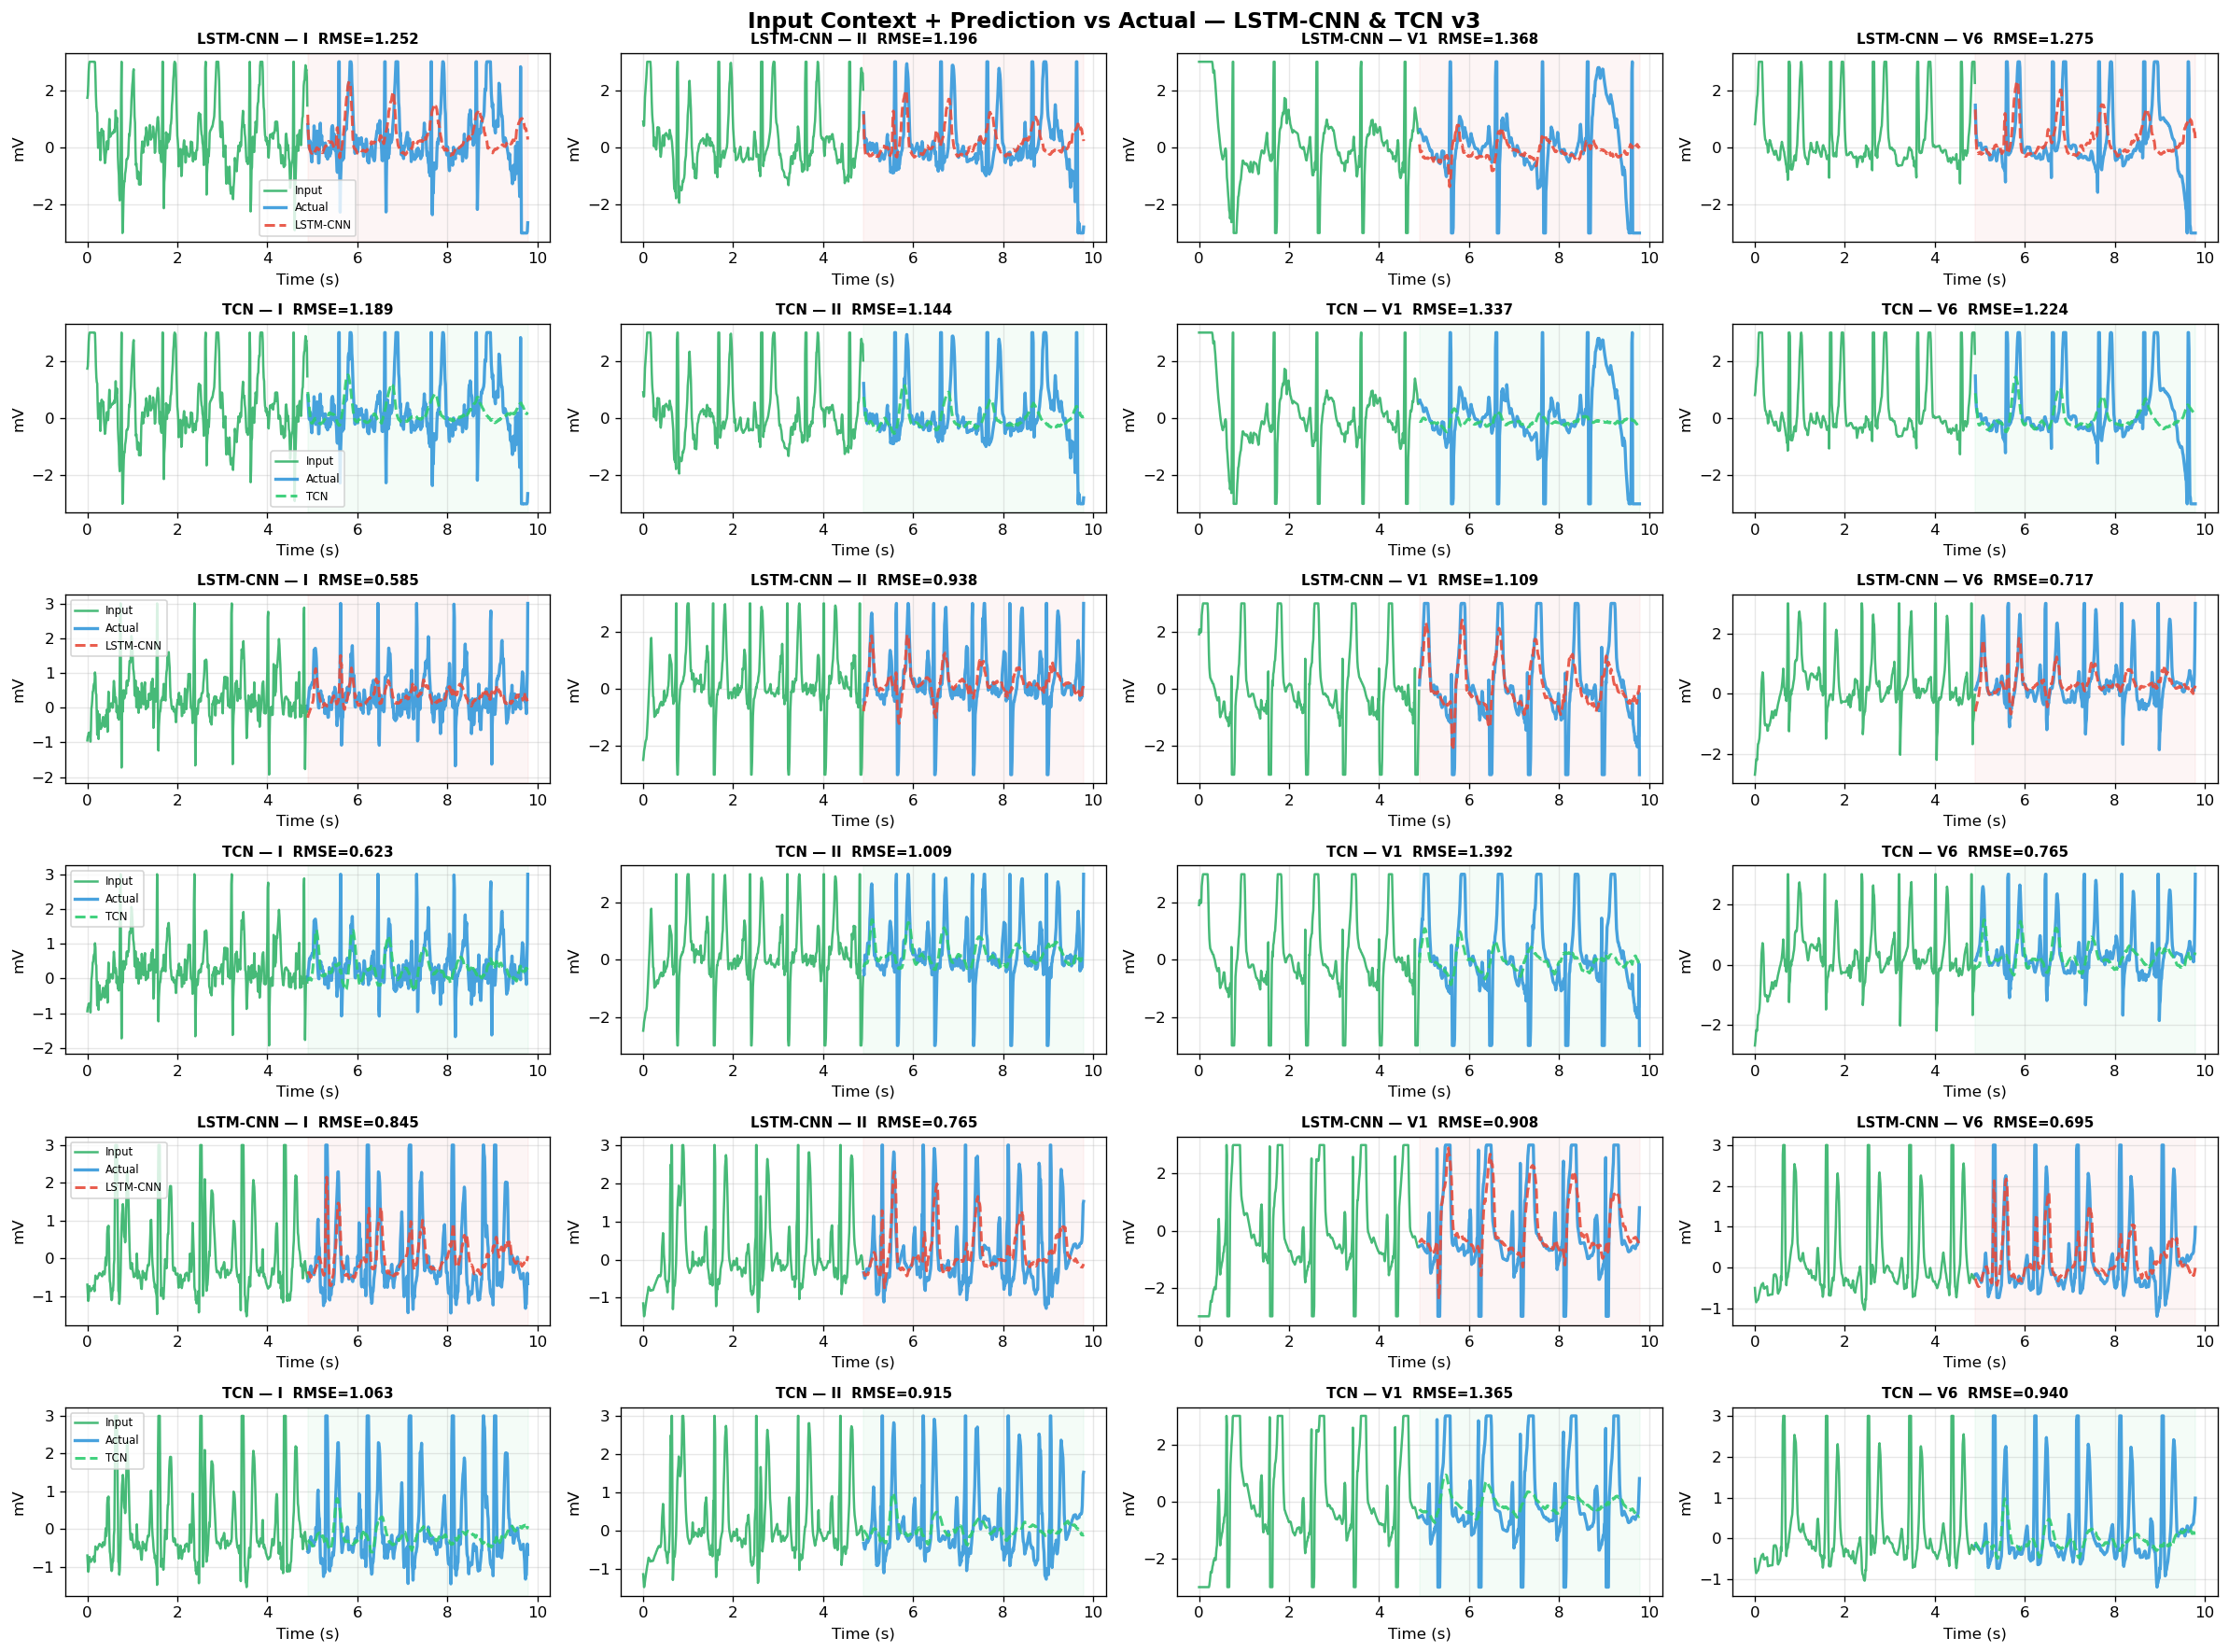

✅ Saved → 05_prediction_context.png


In [14]:
# CELL 11 — PREDICTION OVERLAY (input + forecast context)
# Shows 3 samples: green=input, blue=actual target, red=predicted
n_show = 3
leads_show = [0, 1, 6, 11]   # I, II, V1, V6
t_in  = np.arange(INPUT_LEN) / FS
t_out = np.arange(HORIZON) / FS + INPUT_LEN/FS   # offset to follow input

fig, axes = plt.subplots(n_show*2, len(leads_show), figsize=(20, 5*n_show))

for row in range(n_show):
    for col, li in enumerate(leads_show):
        x_sig = X_xai[row, :, li]
        y_true = y_xai[row, :, li]

        for r_off, (name, preds, color) in enumerate([
            ('LSTM-CNN', wave_preds, '#e74c3c'),
            ('TCN',  tcn_preds,  '#2ecc71'),
        ]):
            ax = axes[row*2 + r_off, col]
            ax.plot(t_in,  x_sig,  color='#27ae60', lw=1.5, label='Input',   alpha=0.85)
            ax.plot(t_out, y_true, color='#3498db', lw=2,   label='Actual',  alpha=0.9)
            ax.plot(t_out, preds[row, :, li],
                           color=color, lw=1.8, label=name, ls='--', alpha=0.9)
            ax.axvspan(INPUT_LEN/FS, (INPUT_LEN+HORIZON)/FS,
                       alpha=0.05, color=color)
            rmse = np.sqrt(np.mean((y_true - preds[row,:,li])**2))
            ax.set_title(f'{name} — {LEAD_NAMES[li]}  RMSE={rmse:.3f}',
                         fontsize=9, fontweight='bold')
            ax.set_xlabel('Time (s)'); ax.set_ylabel('mV')
            ax.grid(True, alpha=0.3)
            if col == 0: ax.legend(fontsize=7)

plt.suptitle('Input Context + Prediction vs Actual — LSTM-CNN & TCN v3',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('05_prediction_context.png')

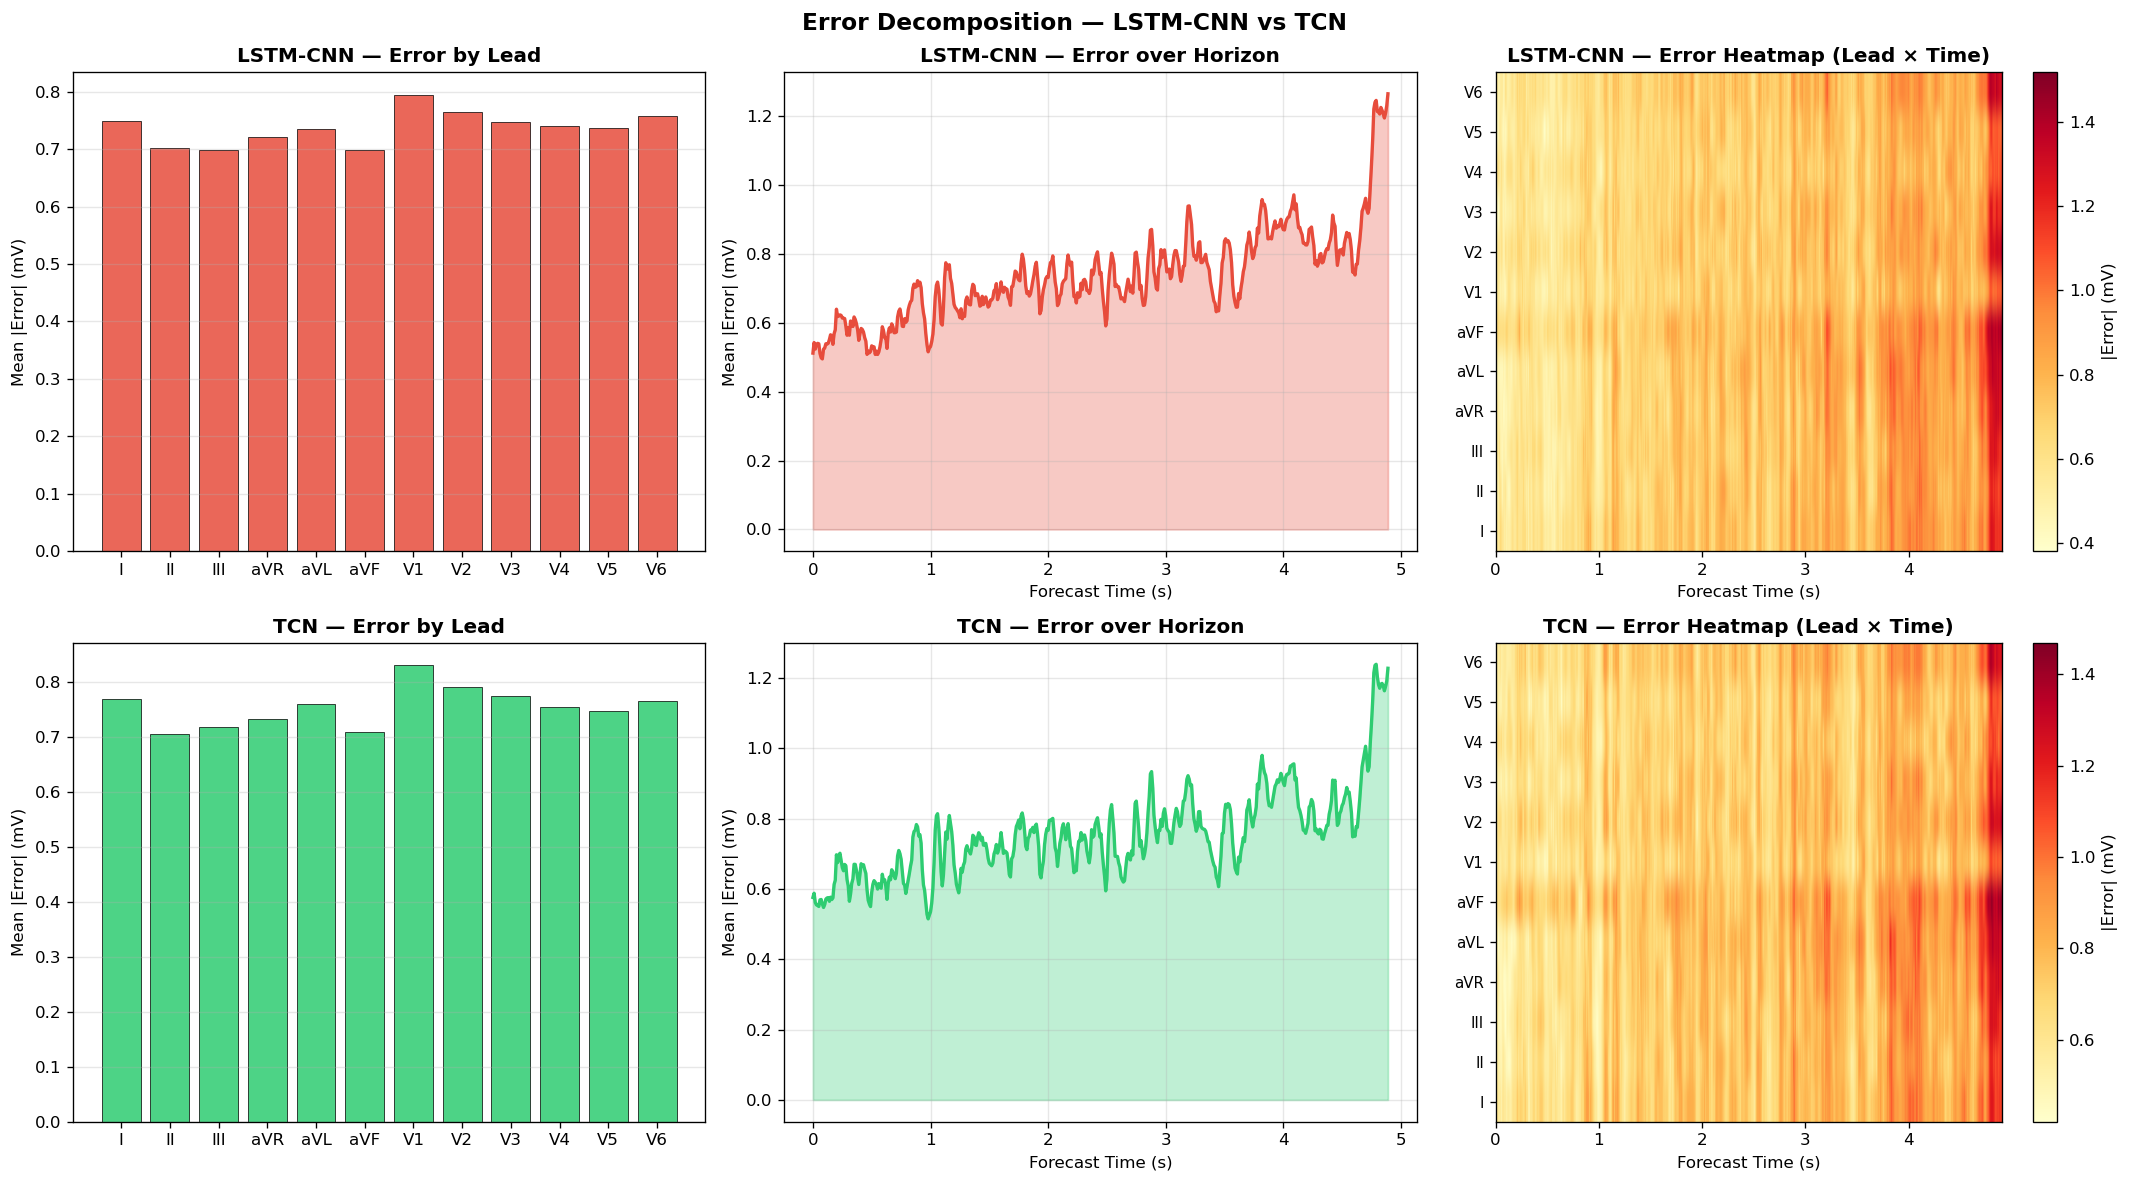

✅ Saved → 06_error_decomposition.png


In [15]:
# CELL 12 — ERROR DECOMPOSITION (by lead, by time, heatmap)
wave_err = wave_preds - y_xai   # (N, HORIZON, 12)
tcn_err  = tcn_preds  - y_xai

t_out = np.arange(HORIZON) / FS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 0: WaveNet
# Row 1: TCN v3
for r, (name, err, color) in enumerate([
    ('LSTM-CNN', wave_err, '#e74c3c'),
    ('TCN',  tcn_err,  '#2ecc71'),
]):
    # Error by lead
    err_lead = np.abs(err).mean(axis=(0,1))
    axes[r,0].bar(LEAD_NAMES, err_lead,
                  color=color, alpha=0.85, edgecolor='black', lw=0.5)
    axes[r,0].set_ylabel('Mean |Error| (mV)'); axes[r,0].grid(alpha=0.3, axis='y')
    axes[r,0].set_title(f'{name} — Error by Lead', fontweight='bold')

    # Error over horizon
    err_time = np.abs(err).mean(axis=(0,2))
    axes[r,1].fill_between(t_out, err_time, alpha=0.3, color=color)
    axes[r,1].plot(t_out, err_time, color=color, lw=2)
    axes[r,1].set_xlabel('Forecast Time (s)'); axes[r,1].set_ylabel('Mean |Error| (mV)')
    axes[r,1].set_title(f'{name} — Error over Horizon', fontweight='bold')
    axes[r,1].grid(alpha=0.3)

    # Error heatmap Lead × Time
    err_hmap = np.abs(err).mean(axis=0).T   # (12, HORIZON)
    im = axes[r,2].imshow(err_hmap, aspect='auto', cmap='YlOrRd',
                          extent=[0, HORIZON/FS, -0.5, N_LEADS-0.5])
    axes[r,2].set_yticks(range(N_LEADS))
    axes[r,2].set_yticklabels(LEAD_NAMES, fontsize=9)
    axes[r,2].set_xlabel('Forecast Time (s)')
    axes[r,2].set_title(f'{name} — Error Heatmap (Lead × Time)',
                        fontweight='bold')
    plt.colorbar(im, ax=axes[r,2], label='|Error| (mV)')

plt.suptitle('Error Decomposition — LSTM-CNN vs TCN',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('06_error_decomposition.png')

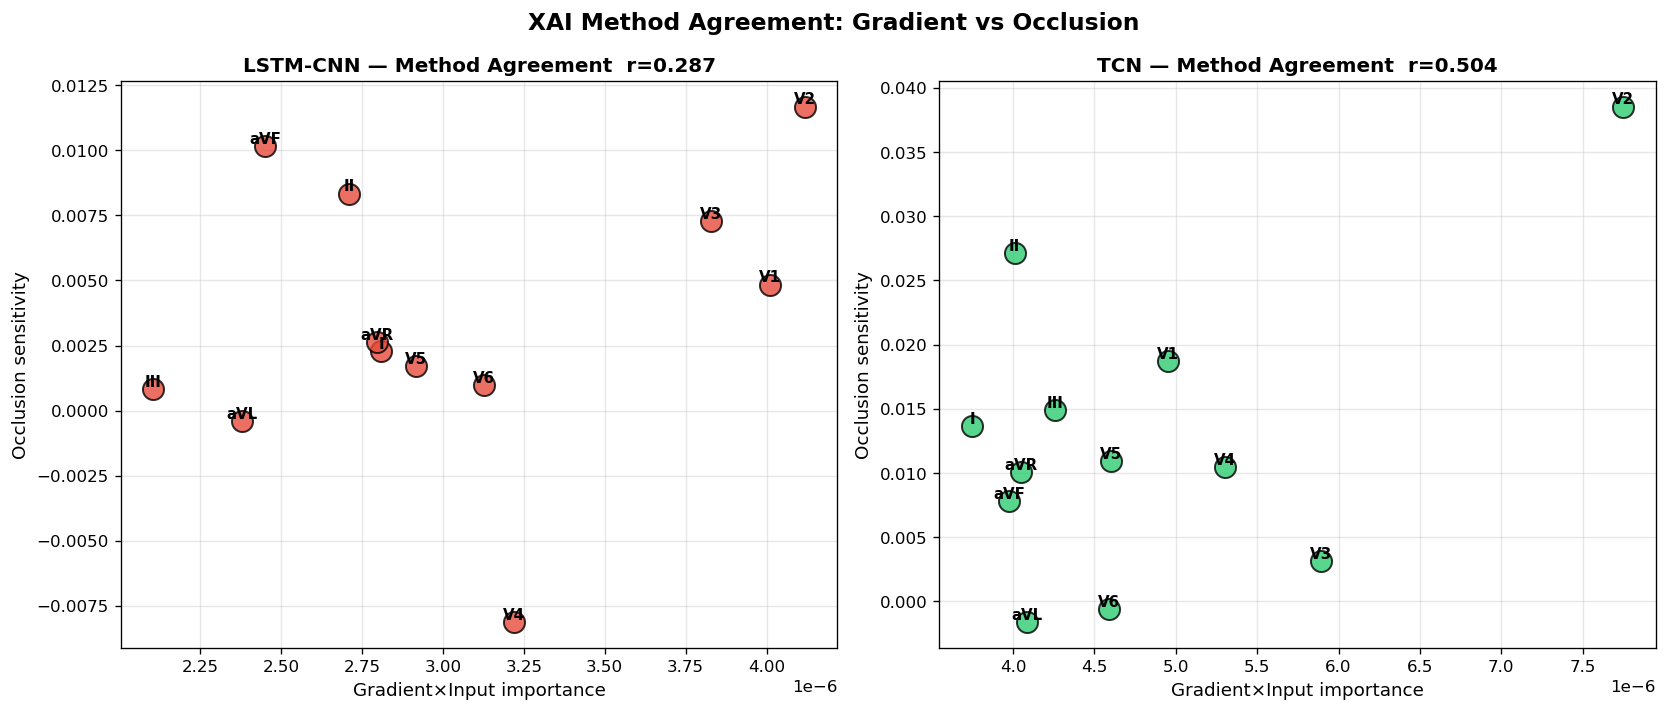

✅ Saved → 07_method_agreement.png
WaveNet method agreement: r=0.287
TCN v3  method agreement: r=0.504


In [16]:
# CELL 13 — METHOD AGREEMENT (gradient vs occlusion correlation)
# Tests whether both XAI methods agree on which leads are important.
# High correlation = consistent, trustworthy attribution.

wave_corr = np.corrcoef(wave_lead_mean, wave_occ)[0,1]
tcn_corr  = np.corrcoef(tcn_lead_mean,  tcn_occ)[0,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, grad, occ, name, color, corr in [
    (axes[0], wave_lead_mean, wave_occ, 'LSTM-CNN', '#e74c3c', wave_corr),
    (axes[1], tcn_lead_mean,  tcn_occ,  'TCN',  '#2ecc71', tcn_corr),
]:
    ax.scatter(grad, occ, s=160, alpha=0.8, color=color,
               edgecolor='black', lw=1.2, zorder=3)
    for i, lead in enumerate(LEAD_NAMES):
        ax.annotate(lead, (grad[i], occ[i]),
                    fontsize=9, ha='center', va='bottom', fontweight='bold')
    ax.set_xlabel('Gradient×Input importance', fontsize=11)
    ax.set_ylabel('Occlusion sensitivity', fontsize=11)
    ax.set_title(f'{name} — Method Agreement  r={corr:.3f}',
                 fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    if corr > 0.7:
        ax.set_facecolor('#f0fff0')
        ax.set_title(f'{name} — ✅ Strong agreement  r={corr:.3f}',
                     fontweight='bold', fontsize=12, color='green')

plt.suptitle('XAI Method Agreement: Gradient vs Occlusion',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('07_method_agreement.png')

print(f"WaveNet method agreement: r={wave_corr:.3f}")
print(f"TCN v3  method agreement: r={tcn_corr:.3f}")

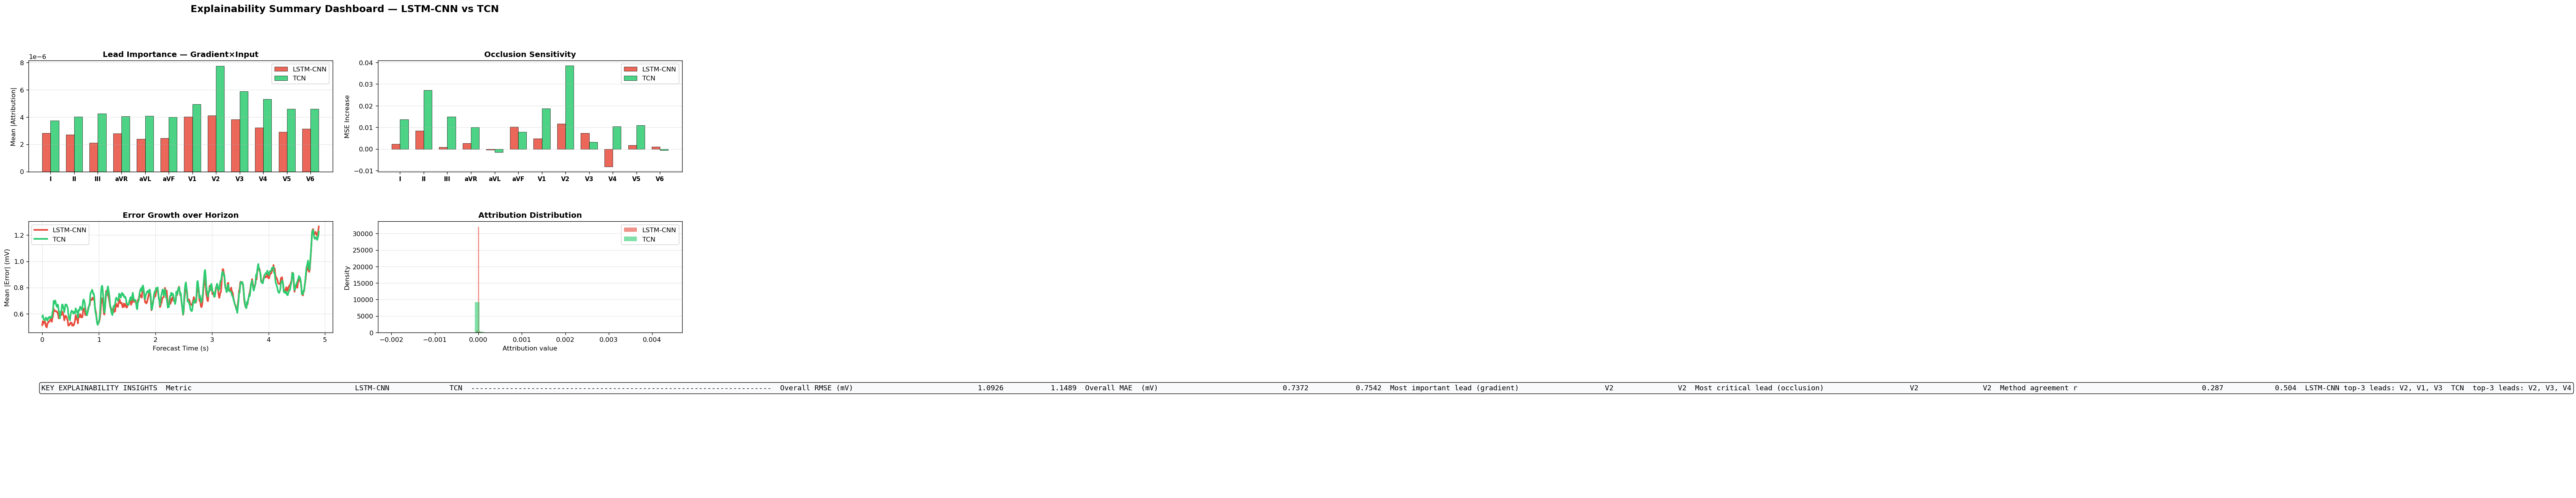

✅ Saved → 08_summary_dashboard.png


In [18]:
# CELL 14 — SUMMARY DASHBOARD
wave_rmse = np.sqrt(np.mean(wave_err**2))
tcn_rmse  = np.sqrt(np.mean(tcn_err**2))
wave_mae  = np.abs(wave_err).mean()
tcn_mae   = np.abs(tcn_err).mean()

wave_top3 = [LEAD_NAMES[i] for i in np.argsort(wave_lead_mean)[-3:][::-1]]
tcn_top3  = [LEAD_NAMES[i] for i in np.argsort(tcn_lead_mean)[-3:][::-1]]
wave_crit = LEAD_NAMES[np.argmax(wave_occ)]
tcn_crit  = LEAD_NAMES[np.argmax(tcn_occ)]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# Lead importance comparison
ax = fig.add_subplot(gs[0, :2])
x  = np.arange(N_LEADS); w = 0.35
ax.bar(x-w/2, wave_lead_mean, w, label='LSTM-CNN', color='#e74c3c', alpha=0.85, edgecolor='black', lw=0.5)
ax.bar(x+w/2, tcn_lead_mean,  w, label='TCN',  color='#2ecc71', alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(LEAD_NAMES, fontsize=9, fontweight='bold')
ax.set_title('Lead Importance — Gradient×Input', fontweight='bold')
ax.set_ylabel('Mean |Attribution|'); ax.legend(); ax.grid(alpha=0.3, axis='y')

# Occlusion comparison
ax = fig.add_subplot(gs[0, 2:])
ax.bar(x-w/2, wave_occ, w, label='LSTM-CNN', color='#e74c3c', alpha=0.85, edgecolor='black', lw=0.5)
ax.bar(x+w/2, tcn_occ,  w, label='TCN',  color='#2ecc71', alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(LEAD_NAMES, fontsize=9, fontweight='bold')
ax.set_title('Occlusion Sensitivity', fontweight='bold')
ax.set_ylabel('MSE Increase'); ax.legend(); ax.grid(alpha=0.3, axis='y')

# Error over horizon
ax = fig.add_subplot(gs[1, :2])
t_out = np.arange(HORIZON) / FS
ax.plot(t_out, np.abs(wave_err).mean(axis=(0,2)), color='#e74c3c', lw=2.5, label='LSTM-CNN')
ax.plot(t_out, np.abs(tcn_err).mean(axis=(0,2)),  color='#2ecc71', lw=2.5, label='TCN')
ax.set_xlabel('Forecast Time (s)'); ax.set_ylabel('Mean |Error| (mV)')
ax.set_title('Error Growth over Horizon', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Attribution distribution
ax = fig.add_subplot(gs[1, 2:])
ax.hist(wave_attr.flatten(), bins=60, color='#e74c3c', alpha=0.6, label='LSTM-CNN', density=True)
ax.hist(tcn_attr.flatten(),  bins=60, color='#2ecc71', alpha=0.6, label='TCN',  density=True)
ax.set_xlabel('Attribution value'); ax.set_ylabel('Density')
ax.set_title('Attribution Distribution', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

# Key insights text
ax = fig.add_subplot(gs[2, :])
ax.axis('off')
lines = [
    "KEY EXPLAINABILITY INSIGHTS",
    "",
    f"  {'Metric':35s}  {'LSTM-CNN':>15s}  {'TCN':>15s}",
    f"  {'-'*70}",
    f"  {'Overall RMSE (mV)':35s}  {wave_rmse:>15.4f}  {tcn_rmse:>15.4f}",
    f"  {'Overall MAE  (mV)':35s}  {wave_mae:>15.4f}  {tcn_mae:>15.4f}",
    f"  {'Most important lead (gradient)':35s}  {wave_top3[0]:>15s}  {tcn_top3[0]:>15s}",
    f"  {'Most critical lead (occlusion)':35s}  {wave_crit:>15s}  {tcn_crit:>15s}",
    f"  {'Method agreement r':35s}  {wave_corr:>15.3f}  {tcn_corr:>15.3f}",
    "",
    f"  LSTM-CNN top-3 leads: {', '.join(wave_top3)}",
    f"  TCN  top-3 leads: {', '.join(tcn_top3)}",
]
ax.text(0.02, 0.98, ''.join(lines), transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.suptitle('Explainability Summary Dashboard — LSTM-CNN vs TCN',
             fontsize=15, fontweight='bold')
save_fig('08_summary_dashboard.png')

In [20]:
# CELL 15 — SAVE RESULTS
results = {
    'lstm_cnn_attr': wave_attr, 'tcn_attr': tcn_attr,
    'lstm_cnn_lead_mean': wave_lead_mean.tolist(),
    'tcn_lead_mean':  tcn_lead_mean.tolist(),
    'lstm_cnn_occ': wave_occ.tolist(), 'tcn_occ': tcn_occ.tolist(),
    'lstm_cnn_corr': float(wave_corr), 'tcn_corr': float(tcn_corr),
    'lstm_cnn_rmse': float(wave_rmse), 'tcn_rmse': float(tcn_rmse),
    'lstm_cnn_mae':  float(wave_mae),  'tcn_mae':  float(tcn_mae),
    'lstm_cnn_top3': wave_top3, 'tcn_top3': tcn_top3,
    'lead_names': LEAD_NAMES, 'horizon_s': HORIZON/FS, 'input_s': INPUT_LEN/FS,
}
path = os.path.join(FIG_DIR, 'explainability_results.pkl')
with open(path, 'wb') as f: pickle.dump(results, f)

print("="*65)
print("  EXPLAINABILITY COMPLETE")
print("="*65)
print(f"  LSTM-CNN RMSE : {wave_rmse:.4f} mV   MAE : {wave_mae:.4f} mV")
print(f"  TCN  RMSE : {tcn_rmse:.4f} mV   MAE : {tcn_mae:.4f} mV")
print(f"  LSTM_CNN top leads : {wave_top3}")
print(f"  TCN   top leads : {tcn_top3}")
print()
print("  Figures saved:")
for i, n in enumerate([
    '01_attribution_heatmaps', '02_temporal_importance',
    '03_lead_importance',      '04_occlusion_sensitivity',
    '05_prediction_context',   '06_error_decomposition',
    '07_method_agreement',     '08_summary_dashboard',
], 1):
    print(f"    {i}. {n}.png")
print(f"\n✅ Results → {path}")

  EXPLAINABILITY COMPLETE
  LSTM-CNN RMSE : 1.0926 mV   MAE : 0.7372 mV
  TCN  RMSE : 1.1489 mV   MAE : 0.7542 mV
  LSTM_CNN top leads : ['V2', 'V1', 'V3']
  TCN   top leads : ['V2', 'V3', 'V4']

  Figures saved:
    1. 01_attribution_heatmaps.png
    2. 02_temporal_importance.png
    3. 03_lead_importance.png
    4. 04_occlusion_sensitivity.png
    5. 05_prediction_context.png
    6. 06_error_decomposition.png
    7. 07_method_agreement.png
    8. 08_summary_dashboard.png

✅ Results → ../reports/figures/explainability/explainability_results.pkl
